In [5]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings("ignore")

# Load file.

In [6]:
df = pd.read_excel("cars.xlsx")

In [7]:
df.head()

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,convertible,rwd,front,64.1,48.8,dohc,130,111,21,27,13495
1,3,?,alfa-romero,gas,convertible,rwd,front,64.1,48.8,dohc,130,111,21,27,16500
2,1,?,alfa-romero,gas,hatchback,rwd,front,65.5,52.4,ohcv,152,154,19,26,16500
3,2,164,audi,gas,sedan,fwd,front,66.2,54.3,ohc,109,102,24,30,13950
4,2,164,audi,gas,sedan,4wd,front,66.4,54.3,ohc,136,115,18,22,17450


# Divide data into Features and Response.

In [8]:
features = df.iloc[ :,  :-1]  # features must of 2D 
response = df.iloc[ : , -1]   # response or target must be 1D

### Handling missing values.

In [9]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   body-style         205 non-null    object 
 5   drive-wheels       205 non-null    object 
 6   engine-location    205 non-null    object 
 7   width              205 non-null    float64
 8   height             205 non-null    float64
 9   engine-type        205 non-null    object 
 10  engine-size        205 non-null    int64  
 11  horsepower         205 non-null    object 
 12  city-mpg           205 non-null    int64  
 13  highway-mpg        205 non-null    int64  
dtypes: float64(2), int64(4), object(8)
memory usage: 22.6+ KB


In [10]:
features.isnull().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
body-style           0
drive-wheels         0
engine-location      0
width                0
height               0
engine-type          0
engine-size          0
horsepower           0
city-mpg             0
highway-mpg          0
dtype: int64

In [11]:
for i in features.columns:
    if "?" in np.array(features[i]):
        print(i)

normalized-losses
horsepower


# Check percentage of missing values.

In [12]:
features["normalized-losses"].value_counts()

normalized-losses
?      41
161    11
91      8
150     7
128     6
104     6
134     6
74      5
103     5
168     5
95      5
102     5
94      5
65      5
85      5
93      4
106     4
118     4
122     4
148     4
154     3
83      3
125     3
115     3
137     3
101     3
194     2
197     2
188     2
164     2
158     2
192     2
110     2
145     2
113     2
81      2
89      2
87      2
108     2
119     2
153     2
129     2
98      1
121     1
107     1
78      1
231     1
142     1
77      1
186     1
90      1
256     1
Name: count, dtype: int64

In [13]:
41/205

0.2

In [14]:
features["horsepower"].value_counts()

horsepower
68     19
70     11
69     10
116     9
110     8
95      7
88      6
114     6
62      6
101     6
160     6
102     5
76      5
97      5
82      5
145     5
84      5
123     4
86      4
92      4
111     4
121     3
90      3
182     3
85      3
73      3
152     3
207     3
112     2
56      2
156     2
161     2
52      2
162     2
?       2
155     2
100     2
94      2
184     2
176     2
115     1
154     1
140     1
48      1
120     1
64      1
135     1
262     1
78      1
60      1
58      1
55      1
288     1
143     1
142     1
200     1
175     1
72      1
134     1
106     1
Name: count, dtype: int64

In [15]:
2/205


0.00975609756097561

- As per the observation "horsepower" have 0.009% missing value so remove it.
- And Normalized losses have 0.20% means we have to replace it.

##### Replacing or handing missing values.

In [16]:
features["normalized-losses"].replace( "?", np.nan, inplace=True)

In [17]:
from sklearn.impute import SimpleImputer

si = SimpleImputer(missing_values=np.nan,  strategy="mean")

features[["normalized-losses"]] = si.fit_transform( features[["normalized-losses"]])

In [18]:
features["normalized-losses"].value_counts()

normalized-losses
122.0    45
161.0    11
91.0      8
150.0     7
128.0     6
104.0     6
134.0     6
103.0     5
168.0     5
74.0      5
102.0     5
94.0      5
65.0      5
95.0      5
85.0      5
106.0     4
118.0     4
148.0     4
93.0      4
154.0     3
83.0      3
125.0     3
101.0     3
137.0     3
115.0     3
194.0     2
197.0     2
192.0     2
158.0     2
164.0     2
119.0     2
81.0      2
110.0     2
145.0     2
188.0     2
89.0      2
87.0      2
153.0     2
108.0     2
129.0     2
113.0     2
98.0      1
121.0     1
107.0     1
78.0      1
231.0     1
142.0     1
77.0      1
186.0     1
90.0      1
256.0     1
Name: count, dtype: int64

##### Remove row of ? from Horsepower column.

In [19]:
features[ features["horsepower"]== "?"]

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg
130,0,122.0,renault,gas,wagon,fwd,front,66.5,55.2,ohc,132,?,23,31
131,2,122.0,renault,gas,hatchback,fwd,front,66.6,50.5,ohc,132,?,23,31


In [20]:
features = features.drop([130, 131], axis=0)
response = response.drop([130, 131], axis=0)

In [21]:
features[ features["horsepower"]== "?"]

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg


In [22]:
 # features["horsepower"].value_counts()

In [23]:
# divide the data into features and respones.
# data should be in numerical format.
# features and response should of equal shape and dimension.

In [24]:
features.shape

(203, 14)

In [25]:
response.shape

(203,)

# Handling outliers.

- a value which at abnormal distance from other values.

<Axes: ylabel='price'>

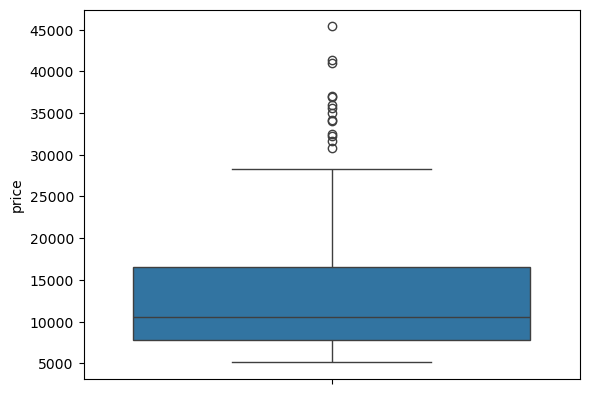

In [26]:
plt.figure()
sns.boxplot( data=features, y= response)

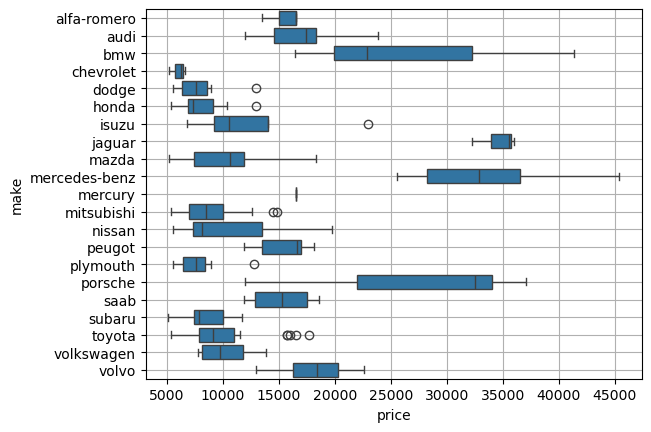

In [27]:
plt.figure()
sns.boxplot( data=features, x= response,  y=features["make"])
plt.grid()

# Removing Outliers.

In [28]:
df[  (df["make"] == "dodge" )  & (df["price"]> 10000)]

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price
29,3,145,dodge,gas,hatchback,fwd,front,66.3,50.2,ohc,156,145,19,24,12964


In [29]:
features.drop(29, axis=0,inplace=True)
response.drop(29, axis=0, inplace=True)

In [30]:
df[  (df["make"] == "honda" )  & (df["price"]> 12000)]

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price
41,0,85,honda,gas,sedan,fwd,front,65.2,54.1,ohc,110,101,24,28,12945


In [31]:
features.drop(41, axis=0,inplace=True)
response.drop(41, axis=0, inplace=True)

In [32]:
df[  (df["make"] == "isuzu" )  & (df["price"]> 15000)]

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price
45,0,?,isuzu,gas,sedan,fwd,front,63.6,52.0,ohc,90,70,38,43,23000


In [33]:
features.drop(45, axis=0,inplace=True)
response.drop(45, axis=0, inplace=True)

In [34]:
df[  (df["make"] == "mitsubishi" )  & (df["price"]> 13000)]

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price
83,3,?,mitsubishi,gas,hatchback,fwd,front,66.3,50.2,ohc,156,145,19,24,14869
84,3,?,mitsubishi,gas,hatchback,fwd,front,66.3,50.2,ohc,156,145,19,24,14489


In [35]:
features.drop([83, 84], axis=0,inplace=True)
response.drop([83, 84], axis=0, inplace=True)

In [36]:
df[  (df["make"] == "plymouth" )  & (df["price"]> 10000)]

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price
124,3,?,plymouth,gas,hatchback,rwd,front,66.3,50.2,ohc,156,145,19,24,12764


In [37]:
features.drop(124, axis=0,inplace=True)
response.drop(124, axis=0, inplace=True)

In [38]:
df[  (df["make"] == "toyota" )  & (df["price"]> 15000)]

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg,price
172,2,134,toyota,gas,convertible,rwd,front,65.6,53.0,ohc,146,116,24,30,17669
178,3,197,toyota,gas,hatchback,rwd,front,67.7,52.0,dohc,171,161,20,24,16558
179,3,197,toyota,gas,hatchback,rwd,front,67.7,52.0,dohc,171,161,19,24,15998
180,-1,90,toyota,gas,sedan,rwd,front,66.5,54.1,dohc,171,156,20,24,15690
181,-1,?,toyota,gas,wagon,rwd,front,66.5,54.1,dohc,161,156,19,24,15750


In [39]:
df[  (df["make"] == "toyota" )  & (df["price"]> 15000)].index

Index([172, 178, 179, 180, 181], dtype='int64')

In [40]:
features.drop([172, 178, 179, 180, 181], axis=0, inplace=True)
response.drop([172, 178, 179, 180, 181], inplace=True)

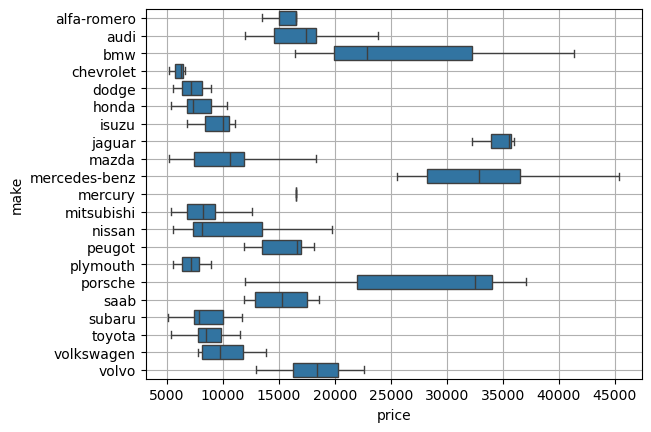

In [41]:
plt.figure()
sns.boxplot( data=features, x= response,  y=features["make"])
plt.grid()

In [42]:
features.shape

(192, 14)

In [43]:
response.shape

(192,)

# Handling Skewness.

##### - it tells the symetry of a dataset or how the data is distribute.

- There are 3 types of skewness 
- - +ve skewness when mean > median
- - symetric     when  mean = median = mode
- - -ve skewness  when mean < median

##### On what kind of data we can remove the skewness.-
- we always remove skewness from the numerical data only.

##### How to check data have skewness or not.
- in python we have scipy.stats  we have module  "skew"
- also sns have distplot for checking skewness.

## Select all the numerical column.

In [44]:
features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 192 entries, 0 to 204
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          192 non-null    int64  
 1   normalized-losses  192 non-null    float64
 2   make               192 non-null    object 
 3   fuel-type          192 non-null    object 
 4   body-style         192 non-null    object 
 5   drive-wheels       192 non-null    object 
 6   engine-location    192 non-null    object 
 7   width              192 non-null    float64
 8   height             192 non-null    float64
 9   engine-type        192 non-null    object 
 10  engine-size        192 non-null    int64  
 11  horsepower         192 non-null    object 
 12  city-mpg           192 non-null    int64  
 13  highway-mpg        192 non-null    int64  
dtypes: float64(3), int64(4), object(7)
memory usage: 22.5+ KB


In [45]:
numcol = features.select_dtypes(["int64", "float64"]).columns

In [46]:
from scipy.stats import skew

In [47]:
print(skew(features["highway-mpg"]))

0.4736409580604422


symboling
0.21680498808856835


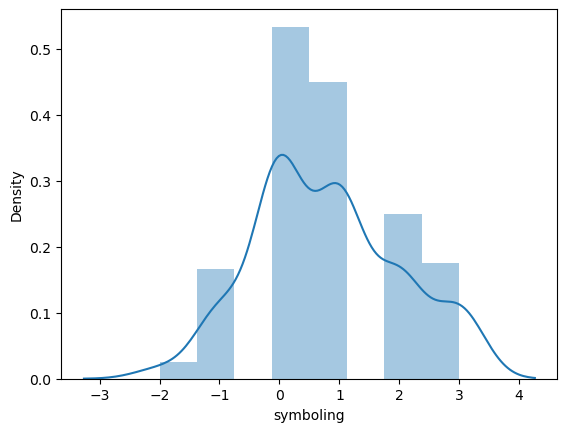

normalized-losses
0.8444205837314254


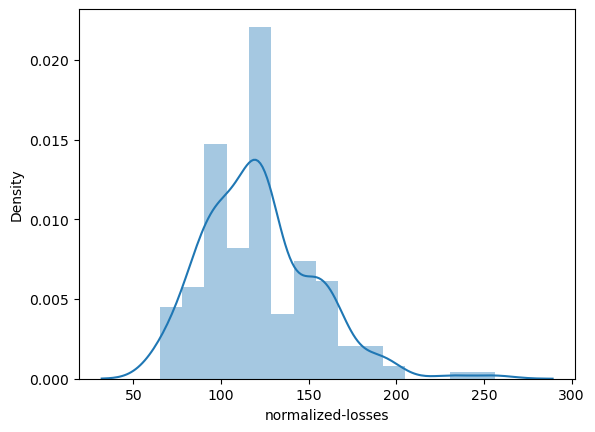

width
0.9196971380212939


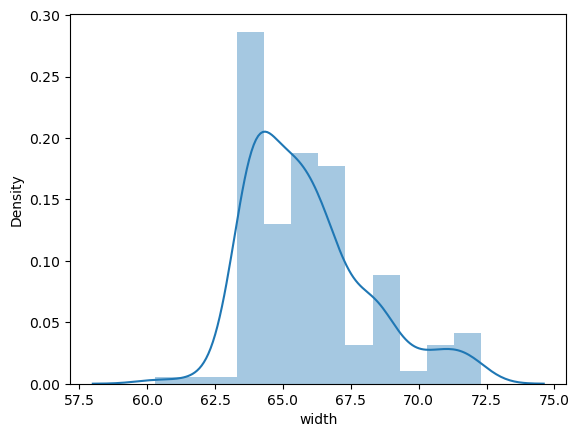

height
0.013754019877847854


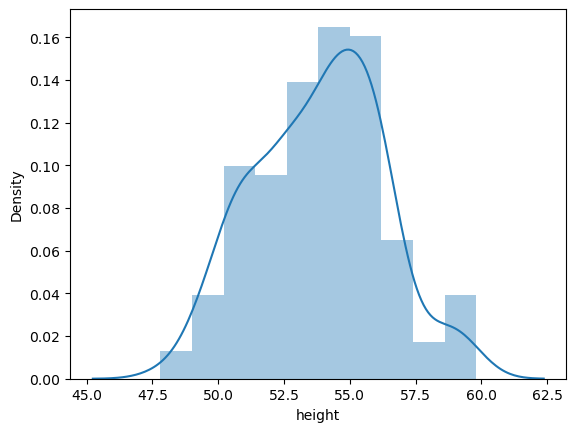

engine-size
2.0489360901881692


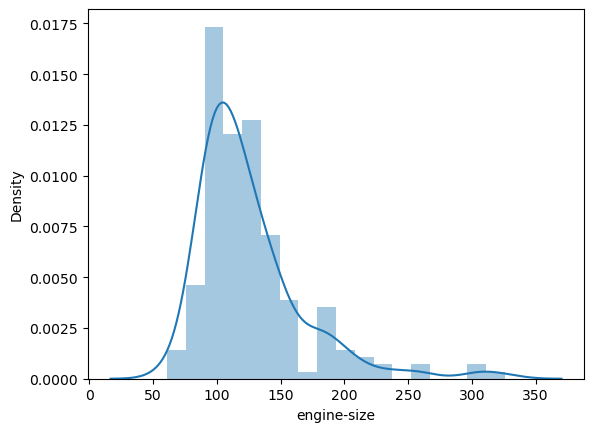

city-mpg
0.5871063086925044


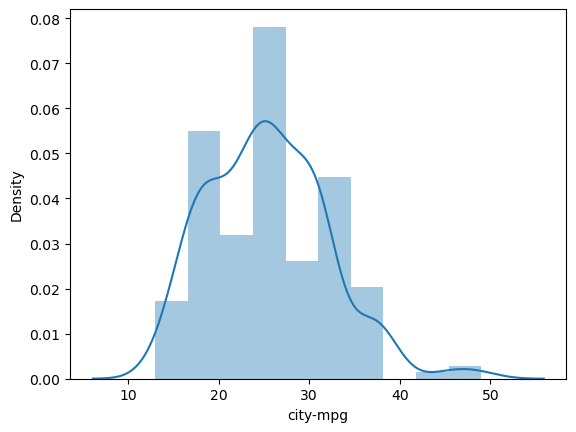

highway-mpg
0.4736409580604422


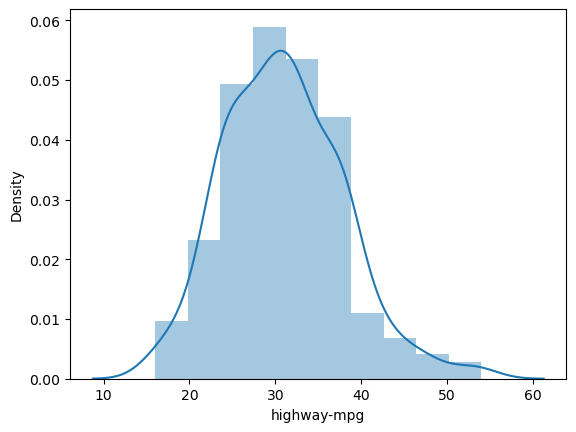

In [48]:
for col in numcol:
    print(col)
    print( skew(features[col]))

    plt.figure()
    sns.distplot(features[col])
    plt.show()



##### There are 2 methods to remove skewness.
- log  transformation
- sqrt transformation

##### Conditions before removing skewness.
- skewed features and response must not have good correlation.
- skewed features must not have any -ve values.

In [49]:
np.log(-3)

np.float64(nan)

In [50]:
np.sqrt(-3)

np.float64(nan)

In [51]:
features.describe()

,symboling,normalized-losses,width,height,engine-size,city-mpg,highway-mpg
count,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000
mean,0.786458,121.395833,65.885417,53.832292,125.562500,25.437500,30.984375
std,1.202625,31.570242,2.199713,2.447009,42.251259,6.575876,6.917976
min,-2.000000,65.000000,60.300000,47.800000,61.000000,13.000000,16.000000
25%,0.000000,100.250000,64.000000,52.000000,97.000000,19.000000,25.000000
50%,1.000000,122.000000,65.400000,54.100000,110.000000,25.000000,30.000000
75%,2.000000,137.000000,66.900000,55.700000,141.000000,30.250000,36.250000
max,3.000000,256.000000,72.300000,59.800000,326.000000,49.000000,54.000000


##### How to find correlation between features and response.

In [52]:
pd.concat([ features[numcol], response], axis=1).corr().style.background_gradient()

,symboling,normalized-losses,width,height,engine-size,city-mpg,highway-mpg,price
symboling,1.000000,0.449579,-0.274301,-0.517320,-0.154550,0.007903,0.084552,-0.095884
normalized-losses,0.449579,1.000000,0.066594,-0.370543,0.090239,-0.212354,-0.168904,0.130188
width,-0.274301,0.066594,1.000000,0.299310,0.735073,-0.641002,-0.678241,0.732925
height,-0.517320,-0.370543,0.299310,1.000000,0.097229,-0.080859,-0.143723,0.146548
engine-size,-0.154550,0.090239,0.735073,0.097229,1.000000,-0.642661,-0.667162,0.871289
city-mpg,0.007903,-0.212354,-0.641002,-0.080859,-0.642661,1.000000,0.970812,-0.683241
highway-mpg,0.084552,-0.168904,-0.678241,-0.143723,-0.667162,0.970812,1.000000,-0.705532
price,-0.095884,0.130188,0.732925,0.146548,0.871289,-0.683241,-0.705532,1.000000


In [53]:
pd.concat([ features[numcol], response], axis=1).corr()["price"]

symboling           -0.095884
normalized-losses    0.130188
width                0.732925
height               0.146548
engine-size          0.871289
city-mpg            -0.683241
highway-mpg         -0.705532
price                1.000000
Name: price, dtype: float64

In [54]:
features["normalized-losses"] = np.log(features['normalized-losses'])

In [55]:
features["height"] = np.log(features["height"])

In [56]:
features.head()

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg
0,3,4.804021,alfa-romero,gas,convertible,rwd,front,64.1,3.887730,dohc,130,111,21,27
1,3,4.804021,alfa-romero,gas,convertible,rwd,front,64.1,3.887730,dohc,130,111,21,27
2,1,4.804021,alfa-romero,gas,hatchback,rwd,front,65.5,3.958907,ohcv,152,154,19,26
3,2,5.099866,audi,gas,sedan,fwd,front,66.2,3.994524,ohc,109,102,24,30
4,2,5.099866,audi,gas,sedan,4wd,front,66.4,3.994524,ohc,136,115,18,22


In [57]:
for col in numcol:
    print(col)
    print( skew(features[col]))

symboling
0.21680498808856835
normalized-losses
0.02289171969989671
width
0.9196971380212939
height
-0.09158287250833391
engine-size
2.0489360901881692
city-mpg
0.5871063086925044
highway-mpg
0.4736409580604422


# Enconding.

- It is a process in "Catergorical" data are converted into "Numerical" data.

- Features and response must be separated.
- All column must be in numerical format.
- Dimension and shape of features and response should be proper.

- get_dummies()
- OneHotEncoder()
- LabelEncoder()
- OrdinalEncoder()

In [58]:
features.head()

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg
0,3,4.804021,alfa-romero,gas,convertible,rwd,front,64.1,3.887730,dohc,130,111,21,27
1,3,4.804021,alfa-romero,gas,convertible,rwd,front,64.1,3.887730,dohc,130,111,21,27
2,1,4.804021,alfa-romero,gas,hatchback,rwd,front,65.5,3.958907,ohcv,152,154,19,26
3,2,5.099866,audi,gas,sedan,fwd,front,66.2,3.994524,ohc,109,102,24,30
4,2,5.099866,audi,gas,sedan,4wd,front,66.4,3.994524,ohc,136,115,18,22


##### Select categorical data.

In [59]:
features["horsepower"]  = features["horsepower"].astype("int")

In [60]:
catcol = features.select_dtypes(object).columns

In [61]:
catcol

Index(['make', 'fuel-type', 'body-style', 'drive-wheels', 'engine-location',
       'engine-type'],
      dtype='object')

In [62]:
features["engine-type"].unique()

array(['dohc', 'ohcv', 'ohc', 'l', 'rotor', 'ohcf', 'dohcv'], dtype=object)

In [63]:
pd.get_dummies(features["engine-type"])  # convert or return equal number of row to the unqiue values in the column and return 1 if value is present.

,dohc,dohcv,l,ohc,ohcf,ohcv,rotor
0,True,False,False,False,False,False,False
1,True,False,False,False,False,False,False
2,False,False,False,False,False,True,False
3,False,False,False,True,False,False,False
4,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...
200,False,False,False,True,False,False,False
201,False,False,False,True,False,False,False
202,False,False,False,False,False,True,False
203,False,False,False,True,False,False,False


##### OneHotEncoder.

In [64]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()

ohe.fit_transform(features[["engine-type"]]).toarray()

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

### LabelEncoder and OrdinalEncoder

- LabelEncoder is suggested to use for Response only.
- As it accept ony one column at a time.



- Oridnal Encoder is suggest to use for featues only.
- It can accpet more then one columns.

In [65]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

In [66]:
le = LabelEncoder()

le.fit_transform(features[["engine-type"]])

array([0, 0, 5, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       0, 0, 5, 3, 3, 3, 3, 3, 6, 6, 6, 6, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 5, 5, 5, 5, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 5, 5, 5, 5, 5, 5, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 1, 3, 3, 3, 3, 0, 0, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 0, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 5, 3, 3])

In [67]:
orden = OrdinalEncoder()

features[catcol] = orden.fit_transform(features[catcol])

In [68]:
features[catcol]

,make,fuel-type,body-style,drive-wheels,engine-location,engine-type
0,0.0,1.0,0.0,2.0,0.0,0.0
1,0.0,1.0,0.0,2.0,0.0,0.0
2,0.0,1.0,2.0,2.0,0.0,5.0
3,1.0,1.0,3.0,1.0,0.0,3.0
4,1.0,1.0,3.0,0.0,0.0,3.0
...,...,...,...,...,...,...
200,20.0,1.0,3.0,2.0,0.0,3.0
201,20.0,1.0,3.0,2.0,0.0,3.0
202,20.0,1.0,3.0,2.0,0.0,5.0
203,20.0,0.0,3.0,2.0,0.0,3.0


In [69]:
features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 192 entries, 0 to 204
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          192 non-null    int64  
 1   normalized-losses  192 non-null    float64
 2   make               192 non-null    float64
 3   fuel-type          192 non-null    float64
 4   body-style         192 non-null    float64
 5   drive-wheels       192 non-null    float64
 6   engine-location    192 non-null    float64
 7   width              192 non-null    float64
 8   height             192 non-null    float64
 9   engine-type        192 non-null    float64
 10  engine-size        192 non-null    int64  
 11  horsepower         192 non-null    int64  
 12  city-mpg           192 non-null    int64  
 13  highway-mpg        192 non-null    int64  
dtypes: float64(9), int64(5)
memory usage: 22.5 KB


In [70]:
features.head()

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg
0,3,4.804021,0.0,1.0,0.0,2.0,0.0,64.1,3.887730,0.0,130,111,21,27
1,3,4.804021,0.0,1.0,0.0,2.0,0.0,64.1,3.887730,0.0,130,111,21,27
2,1,4.804021,0.0,1.0,2.0,2.0,0.0,65.5,3.958907,5.0,152,154,19,26
3,2,5.099866,1.0,1.0,3.0,1.0,0.0,66.2,3.994524,3.0,109,102,24,30
4,2,5.099866,1.0,1.0,3.0,0.0,0.0,66.4,3.994524,3.0,136,115,18,22


In [71]:
features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 192 entries, 0 to 204
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          192 non-null    int64  
 1   normalized-losses  192 non-null    float64
 2   make               192 non-null    float64
 3   fuel-type          192 non-null    float64
 4   body-style         192 non-null    float64
 5   drive-wheels       192 non-null    float64
 6   engine-location    192 non-null    float64
 7   width              192 non-null    float64
 8   height             192 non-null    float64
 9   engine-type        192 non-null    float64
 10  engine-size        192 non-null    int64  
 11  horsepower         192 non-null    int64  
 12  city-mpg           192 non-null    int64  
 13  highway-mpg        192 non-null    int64  
dtypes: float64(9), int64(5)
memory usage: 22.5 KB


### Features Scalling.

When to use ?
- When we have handle the highly varience magnitude.

What is does ?
- Brining data's into a same range ( same scale ).

In [72]:
n1 = 10 # kg
n2 = 1000 # grams

n1 > n2

False

##### To do so.

There are 2 method
- standerscaler   # 90% problem can be solve.
- min max scaler  

### Min max Scaler.
- Formula :     (arr - arr.min)  /   (arr.max - arr.min)

In [73]:
arr1 = np.array([ 1, 2, 3, 4, 5] )
arr2 = np.array( [10, 20, 30, 40, 50 ])
arr3 = np.array( [100, 200, 300, 400, 500])

In [74]:
def minmax(arr):
    return (arr- arr.min())/ (arr.max() - arr.min())

In [75]:
minmax(arr1)

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

In [76]:
minmax(arr2)

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

In [77]:
minmax(arr3)

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

In [78]:
features.head()

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg
0,3,4.804021,0.0,1.0,0.0,2.0,0.0,64.1,3.887730,0.0,130,111,21,27
1,3,4.804021,0.0,1.0,0.0,2.0,0.0,64.1,3.887730,0.0,130,111,21,27
2,1,4.804021,0.0,1.0,2.0,2.0,0.0,65.5,3.958907,5.0,152,154,19,26
3,2,5.099866,1.0,1.0,3.0,1.0,0.0,66.2,3.994524,3.0,109,102,24,30
4,2,5.099866,1.0,1.0,3.0,0.0,0.0,66.4,3.994524,3.0,136,115,18,22


In [79]:
from sklearn.preprocessing import minmax_scale

minmax = minmax_scale(features)

In [80]:
minmax

array([[1.        , 0.45932177, 0.        , ..., 0.2625    , 0.22222222,
        0.28947368],
       [1.        , 0.45932177, 0.        , ..., 0.2625    , 0.22222222,
        0.28947368],
       [0.6       , 0.45932177, 0.        , ..., 0.44166667, 0.16666667,
        0.26315789],
       ...,
       [0.2       , 0.27684005, 1.        , ..., 0.35833333, 0.13888889,
        0.18421053],
       [0.2       , 0.27684005, 1.        , ..., 0.24166667, 0.36111111,
        0.28947368],
       [0.2       , 0.27684005, 1.        , ..., 0.275     , 0.16666667,
        0.23684211]])

##### SanderScaler

- Fromula :   arr- arr.mean/ arr.std

In [81]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

features.iloc[ : ,  : ] = sc.fit_transform(features.iloc[ : ,  : ] )

In [82]:

sc.fit_transform(features.iloc[ : , : ] )

array([[ 1.84540319,  0.1469278 , -1.98865048, ...,  0.21793307,
        -0.67657925, -0.57745092],
       [ 1.84540319,  0.1469278 , -1.98865048, ...,  0.21793307,
        -0.67657925, -0.57745092],
       [ 0.17802713,  0.1469278 , -1.98865048, ...,  1.30905221,
        -0.98151638, -0.72237978],
       ...,
       [-1.48934893, -0.83666999,  1.39929   , ...,  0.80155494,
        -1.13398494, -1.15716636],
       [-1.48934893, -0.83666999,  1.39929   , ...,  0.09105876,
         0.08576357, -0.57745092],
       [-1.48934893, -0.83666999,  1.39929   , ...,  0.29405766,
        -0.98151638, -0.86730864]])

In [83]:
features.head()

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg
0,1.845403,0.146928,-1.988650,0.340997,-3.116631,1.224406,-0.125988,-0.813781,-2.138062,-3.095684,0.105301,0.217933,-0.676579,-0.577451
1,1.845403,0.146928,-1.988650,0.340997,-3.116631,1.224406,-0.125988,-0.813781,-2.138062,-3.095684,0.105301,0.217933,-0.676579,-0.577451
2,0.178027,0.146928,-1.988650,0.340997,-0.746757,1.224406,-0.125988,-0.175670,-0.571031,1.932838,0.627357,1.309052,-0.981516,-0.722380
3,1.011715,1.310228,-1.819253,0.340997,0.438180,-0.570143,-0.125988,0.143385,0.213133,-0.078571,-0.393025,-0.010441,-0.219174,-0.142664
4,1.011715,1.310228,-1.819253,0.340997,0.438180,-2.364693,-0.125988,0.234544,0.213133,-0.078571,0.247680,0.319433,-1.133985,-1.302095


# Features Engineering.

- Selection of columns, or making new columns, etc.

In [84]:
features.head()

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg
0,1.845403,0.146928,-1.988650,0.340997,-3.116631,1.224406,-0.125988,-0.813781,-2.138062,-3.095684,0.105301,0.217933,-0.676579,-0.577451
1,1.845403,0.146928,-1.988650,0.340997,-3.116631,1.224406,-0.125988,-0.813781,-2.138062,-3.095684,0.105301,0.217933,-0.676579,-0.577451
2,0.178027,0.146928,-1.988650,0.340997,-0.746757,1.224406,-0.125988,-0.175670,-0.571031,1.932838,0.627357,1.309052,-0.981516,-0.722380
3,1.011715,1.310228,-1.819253,0.340997,0.438180,-0.570143,-0.125988,0.143385,0.213133,-0.078571,-0.393025,-0.010441,-0.219174,-0.142664
4,1.011715,1.310228,-1.819253,0.340997,0.438180,-2.364693,-0.125988,0.234544,0.213133,-0.078571,0.247680,0.319433,-1.133985,-1.302095


##### Area of Rectangle = width * height

In [85]:
features[ "Area"  ] =   features["width"] * features["height"]

In [86]:
features.head()

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,width,height,engine-type,engine-size,horsepower,city-mpg,highway-mpg,Area
0,1.845403,0.146928,-1.988650,0.340997,-3.116631,1.224406,-0.125988,-0.813781,-2.138062,-3.095684,0.105301,0.217933,-0.676579,-0.577451,1.739914
1,1.845403,0.146928,-1.988650,0.340997,-3.116631,1.224406,-0.125988,-0.813781,-2.138062,-3.095684,0.105301,0.217933,-0.676579,-0.577451,1.739914
2,0.178027,0.146928,-1.988650,0.340997,-0.746757,1.224406,-0.125988,-0.175670,-0.571031,1.932838,0.627357,1.309052,-0.981516,-0.722380,0.100313
3,1.011715,1.310228,-1.819253,0.340997,0.438180,-0.570143,-0.125988,0.143385,0.213133,-0.078571,-0.393025,-0.010441,-0.219174,-0.142664,0.030560
4,1.011715,1.310228,-1.819253,0.340997,0.438180,-2.364693,-0.125988,0.234544,0.213133,-0.078571,0.247680,0.319433,-1.133985,-1.302095,0.049989


In [87]:
features.drop(["width", "height"], axis=1, inplace=True)

- Features and Response
- numerical 
- check shape and size.

In [88]:
features.shape

(192, 13)

In [89]:
response.shape

(192,)

# Train_Test and_Split

In [113]:
from sklearn.model_selection  import train_test_split

In [114]:
xtrain, xtest, ytrain, ytest   = train_test_split( features, response, test_size= 0.20, random_state= 3 )

In [115]:
xtrain

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,engine-type,engine-size,horsepower,city-mpg,highway-mpg,Area
142,-0.655661,-0.557112,0.891099,0.340997,0.438180,-0.570143,-0.125988,0.927134,-0.416755,-0.517938,0.390701,0.292122,0.117053
67,-1.489349,-0.920335,-0.464077,-2.932576,0.438180,1.224406,-0.125988,-0.078571,1.362981,0.522431,-0.524111,-0.867309,2.188274
61,0.178027,0.366306,-0.633474,0.340997,-0.746757,-0.570143,-0.125988,-0.078571,-0.084537,-0.467188,0.085764,0.147193,-0.008822
91,0.178027,0.335706,0.044114,0.340997,0.438180,-0.570143,-0.125988,-0.078571,-0.677783,-0.847811,0.848106,0.871838,-0.279524
88,-1.489349,0.602896,-0.125283,0.340997,0.438180,-0.570143,-0.125988,-0.078571,-0.369295,0.344807,-0.371642,-0.142664,0.201282
...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,1.845403,0.146928,-1.988650,0.340997,-3.116631,1.224406,-0.125988,-3.095684,0.105301,0.217933,-0.676579,-0.577451,1.739914
197,-1.489349,-1.818961,1.399290,0.340997,1.623117,1.224406,-0.125988,-0.078571,0.366329,0.294058,-0.219174,-0.432522,0.883066
139,1.011715,-1.367649,0.891099,0.340997,-0.746757,-0.570143,-0.125988,0.927134,-0.416755,-0.746312,0.085764,0.002265,0.032806
160,-0.655661,-1.005820,1.060496,0.340997,0.438180,-0.570143,-0.125988,-0.078571,-0.654053,-0.822436,1.915386,2.321126,0.216904


In [116]:
xtest

,symboling,normalized-losses,make,fuel-type,body-style,drive-wheels,engine-location,engine-type,engine-size,horsepower,city-mpg,highway-mpg,Area
39,-0.655661,-1.274023,-1.141665,0.340997,0.438180,-0.570143,-0.125988,-0.078571,-0.369295,-0.416439,0.238232,0.292122,-0.041204
100,-0.655661,-0.405858,0.044114,0.340997,0.438180,-0.570143,-0.125988,-0.078571,-0.131997,-0.137315,0.238232,0.437051,-0.117066
162,-0.655661,-1.005820,1.060496,0.340997,0.438180,-0.570143,-0.125988,-0.078571,-0.654053,-0.822436,0.390701,0.437051,0.273259
3,1.011715,1.310228,-1.819253,0.340997,0.438180,-0.570143,-0.125988,-0.078571,-0.393025,-0.010441,-0.219174,-0.142664,0.030560
73,-0.655661,0.146928,-0.464077,0.340997,0.438180,1.224406,-0.125988,1.932838,4.329207,2.070298,-1.743859,-2.171668,3.088421
138,1.011715,-1.367649,0.891099,0.340997,-0.746757,-0.570143,-0.125988,0.927134,-0.677783,-0.847811,0.848106,0.726909,0.035677
35,-0.655661,-0.260207,-1.141665,0.340997,0.438180,-0.570143,-0.125988,-0.078571,-0.796432,-0.670187,0.695638,0.437051,-0.252717
6,0.178027,1.163673,-1.819253,0.340997,0.438180,-0.570143,-0.125988,-0.078571,0.247680,0.192558,-0.981516,-0.867309,1.944390
114,-0.655661,0.146928,0.213511,-2.932576,1.623117,1.224406,-0.125988,-1.084275,0.627357,-0.188065,-0.066705,-0.867309,2.210353
80,1.845403,1.037227,-0.125283,0.340997,-0.746757,-0.570143,-0.125988,-0.078571,-0.369295,0.344807,-0.371642,-0.142664,0.413520


# Model_Selection

# Model_Evaluation

#from sklearn.metrics  import mean_squared_error, r2_score

##mse = mean_squared_error(ytest, yp)
#r2  = r2_score(ytest, yp)

## Check  the model is in Underfitting or Overfitting

#train = linreg.score(xtrain, ytrain)
#test  = linreg.score(xtest, ytest)

# Today_Ridge

## Model_Selection

In [117]:
from sklearn.linear_model import Lasso,Ridge
l2 = Ridge(alpha=4)

l2.fit(xtrain, ytrain)

yp = l2.predict(xtest)

# Model_Evaluation

In [118]:
from sklearn.metrics import mean_squared_error, mean_absolute_error ,root_mean_squared_error,r2_score

In [119]:
mae= mean_absolute_error(yp,ytest)
mse= mean_squared_error(yp,ytest)
rmse=root_mean_squared_error(yp,ytest)
r2=root_mean_squared_error(yp,ytest)

In [120]:
print(mae)
print(mse)
print(rmse)
print(r2)

2028.626641905755
6785442.560173936
2604.888204928176
2604.888204928176


# Check for overfitting and Underfitting

In [121]:
train = l2.score(xtrain, ytrain)
test  = l2.score(xtest, ytest)

In [122]:
print(f"Training score is : {train}")
print(f"Testing  score is : {test}")

Training score is : 0.8525596598775385
Testing  score is : 0.8851611559832111


# Find The best value for alpha

In [123]:
for i in range(1,101):
    l2=Ridge(alpha=i)
    l2.fit(xtrain,ytrain)
    yp=l2.predict(xtest)

    train=l2.score(xtrain,ytrain)
    test=l2.score(xtest,ytest)

    print(train," ", test)

0.8534560574404084   0.8797103280203715
0.8532163831532454   0.8820087236089339
0.852911460051485   0.8837593039293777
0.8525596598775385   0.8851611559832111
0.8521702213114866   0.8863125047342502
0.8517494676452657   0.8872700583950985
0.8513023689587318   0.8880704434088823
0.8508330345492204   0.8887393150528681
0.8503449204963437   0.8892957363853594
0.8498409496497419   0.8897544987429885
0.8493235984208346   0.8901274537327563
0.8487949666140888   0.8904243304683062
0.8482568357889378   0.8906532658427196
0.8477107185318692   0.8908211652117322
0.8471579000866997   0.8909339576602293
0.8465994734720976   0.8909967827965679
0.8460363690571715   0.8910141313329953
0.845469379445188   0.8909899534141789
0.8448991804042413   0.8909277437722646
0.8443263484792318   0.8908306098039112
0.8437513758239581   0.8907013267808519
0.8431746827072384   0.8905423831792568
0.8425966280732907   0.8903560182927461
0.8420175184737093   0.8901442537311532
0.841437615635329   0.8899089200123133
0.8

#  Retrain  after  Hyperparameter  Tunning

#Model_selection

In [124]:
from sklearn.linear_model import Lasso,Ridge
l2 = Ridge(alpha=4)

l2.fit(xtrain, ytrain)

yp = l2.predict(xtest)

# Model_Evaluation

In [125]:
mae= mean_absolute_error(yp,ytest)
mse= mean_squared_error(yp,ytest)
rmse=root_mean_squared_error(yp,ytest)
r2=root_mean_squared_error(yp,ytest)

In [126]:
print(mae)
print(mse)
print(rmse)
print(r2)

2028.626641905755
6785442.560173936
2604.888204928176
2604.888204928176


In [127]:
train = l2.score(xtrain, ytrain)
test  = l2.score(xtest, ytest)

In [128]:
print(f"Training score is : {train}")
print(f"Testing  score is : {test}")

Training score is : 0.8525596598775385
Testing  score is : 0.8851611559832111


# Now Using Lasso (L1)

In [129]:
from sklearn.linear_model import Lasso,Ridge

# Model_selection

In [130]:
l1 = Lasso(alpha=4)

l1.fit(xtrain, ytrain)

yp = l1.predict(xtest)

# Model_Evaluation

In [131]:
from sklearn.metrics import mean_squared_error, mean_absolute_error ,root_mean_squared_error,r2_score

In [136]:
mae= mean_absolute_error(yp,ytest)
mse= mean_squared_error(yp,ytest)
rmse=root_mean_squared_error(yp,ytest)
r2=root_mean_squared_error(yp,ytest)

In [137]:
print(mae)
print(mse)
print(rmse)
print(r2)

2104.739367396456
7210656.720571392
2685.2666013957332
2685.2666013957332


# check for over and underfitting

In [138]:
train = l1.score(xtrain, ytrain)
test  = l1.score(xtest, ytest)

In [139]:
print(f"Training score is : {train}")
print(f"Testing  score is : {test}")

Training score is : 0.8535397729851906
Testing  score is : 0.8779647053159814
